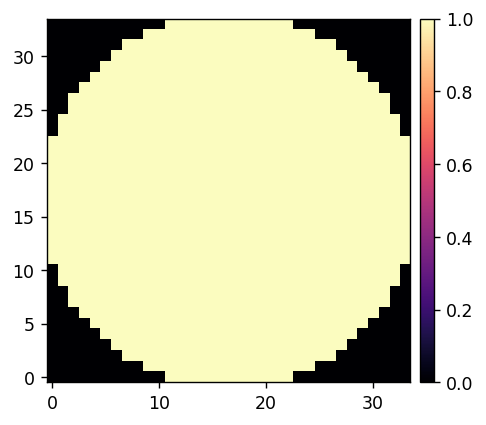

In [51]:
import numpy as np
import astropy.units as u
import threading as th
import time 
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output
from importlib import reload
import copy
import os
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

import scoob_llowfsc
from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc import utils
from scoob_llowfsc import dm
from scoob_llowfsc import telem
import scoob_llowfsc.scoob_interface as scoobi
from scoob_llowfsc import iefc

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient
client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()
    client = IndiClient()
    client.connect()
    client.get_properties()

wavelength = 633e-9

wavelength_c = 633e-9
camsci_pxscl = 4.6e-6
camsci_pxscl_lamDc = 0.307

dm_mask = ensure_np_array(dm.make_mask(34))
utils.imshow([dm_mask])

data_path = scoob_llowfsc.path/'exp-data'

# Setup SHMIM names and directory paths.

In [52]:
camsci_name = 'camlo'
dm_ho_name = 'dm00disp03'

camsci_rawims_path = Path(f'/opt/MagAOX/rawimages/{camsci_name}/')
dm_ho_rawims_path = Path(f'/opt/MagAOX/rawimages/{dm_ho_name}/')

# date = 20250409
# date = 20250410
date = today
exp_path = data_path/f'exp-{date}'
iefc_data_path = data_path/f'exp-{today}'/'iefc'
iefc_telem_path = iefc_data_path/'raw-telem'
iefc_unpacked_path = iefc_data_path/'unpacked-telem'

In [53]:
telem.make_dir(exp_path)
telem.make_dir(iefc_data_path)
telem.make_dir(iefc_telem_path)
telem.make_dir(iefc_unpacked_path)

Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250415' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250415/iefc' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250415/iefc/raw-telem' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250415/iefc/unpacked-telem' already exists.


# Set science camera ROI

In [54]:
reload(scoobi)
xc, yc = (3725, 2500)
npsf = 256
scoobi.set_cam_roi(xc, yc, npsf, client0, cam_name=camsci_name, bin_mode=2)
scoobi.set_cam_exp_time(0.001, client0, cam_name=camsci_name,)
scoobi.set_cam_gain(120, client0, cam_name=camsci_name,)
scoobi.set_cam_blacklevel(2, client0, cam_name=camsci_name,)

Set camlo ROI.
Set the camlo exposure time to 1.00e-03s
Set the camlo gain setting to 120.0
Set the camlo blacklevel to 2.0


# Home and move the beam block out the way.

In [55]:
scoobi.home_block(client0)

In [56]:
scoobi.move_block_out(client0)

# Setup the camera and DM shmim streams.

In [70]:
camsci_stream = ImageStream(camsci_name)
dm_ho_stream = ImageStream(dm_ho_name)


# Move PSF off of vortex to get a reference PSF measurement so we can normalize coronagraphic images.

In [63]:
scoobi.move_psf(50, 0, client0)

In [68]:
scoobi.move_psf(0, -50, client0)

In [57]:
reload(scoobi)
scoobi.set_fib_atten(28, client)
scoobi.set_cam_exp_time(0.0002, client0, cam_name=camsci_name)
scoobi.set_cam_gain(120, client0, cam_name=camsci_name)


Set the fiber attenuation to 28.0
Set the camlo exposure time to 2.00e-04s
Set the camlo gain setting to 120.0


INFO:utils:Got semaphore index 1.


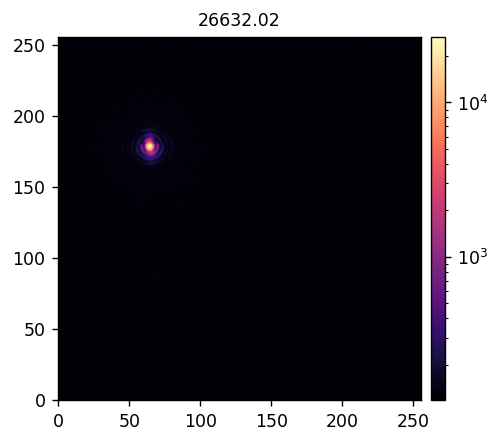

In [71]:
reload(scoobi)
ref_psf = scoobi.snap(camsci_stream, 200)
Iref = np.max(ref_psf)
utils.imshow([ref_psf], titles=[f'{Iref:.2f}'], norms=[LogNorm()])

In [72]:
reload(scoobi)
ref_psf_params = scoobi.get_im_params(client0, client, cam_name=camsci_name)
ref_psf_params.update({
    'Iref': Iref,
    'atten':28.0,
})
print(ref_psf_params)

utils.save_pickle(iefc_data_path/f'ref_psf_params.pkl', ref_psf_params)
utils.save_fits(iefc_data_path/'ref_psf.fits', ref_psf, header=ref_psf_params)

# ref_psf_params = utils.load_pickle(data_path/f'{today}_ref_psf_params.pkl')
# ref_psf = utils.load_fits(iefc_data_path/'ref_psf.fits')
# utils.imshow([ref_psf], titles=[f'{ref_psf_params["Iref"]:.2f}'], norms=[LogNorm()])
# print(ref_psf_params)

{'texp': 0.000199999994947575, 'gain': 120.0, 'atten': 28.0, 'Iref': np.float64(26632.02)}
Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250415/iefc/ref_psf_params.pkl
Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250415/iefc/ref_psf.fits


# Move back onto the vortex and adjust exposure times

In [80]:
scoobi.move_psf(-20, 0, client0)

In [86]:
scoobi.move_psf(0, 50, client0)

In [107]:
scoobi.move_psf(-1, 0, client0)

In [114]:
scoobi.move_psf(0, -1, client0)

In [115]:
scoobi.set_fib_atten(0, client)
scoobi.set_cam_exp_time(0.005, client0, cam_name=camsci_name)
scoobi.set_cam_gain(120, client0, cam_name=camsci_name)

im_params = scoobi.get_im_params(client0, client, cam_name=camsci_name)
im_params.update({'atten':0.0})
print(im_params)

Set the fiber attenuation to 0.0
Set the camlo exposure time to 5.00e-03s
Set the camlo gain setting to 120.0
{'texp': 0.00499999988824129, 'gain': 120.0, 'atten': 0.0}


In [116]:
reload(scoobi)
scoobi.move_block_in(client0)

128.5939865722656
Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250415/iefc/camsci_dark_frame_0.005000.pkl


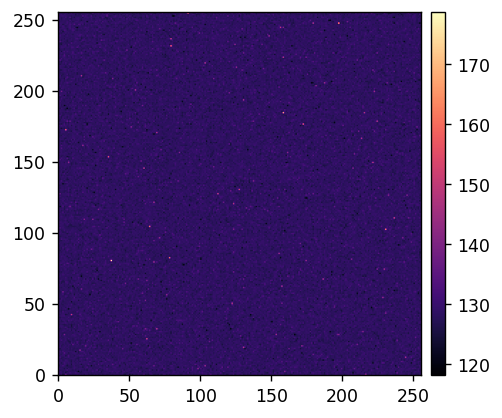

In [117]:
reload(scoobi)
dark_frame = scoobi.snap(camsci_stream, 500)
print(np.mean(dark_frame))
utils.save_pickle(iefc_data_path/f'camsci_dark_frame_{im_params["texp"]:.6f}.pkl', dark_frame)

utils.imshow([dark_frame])

In [118]:
reload(scoobi)
scoobi.move_block_out(client0)

# Use a waffle pattern to figure out the centering of the science camera images. 

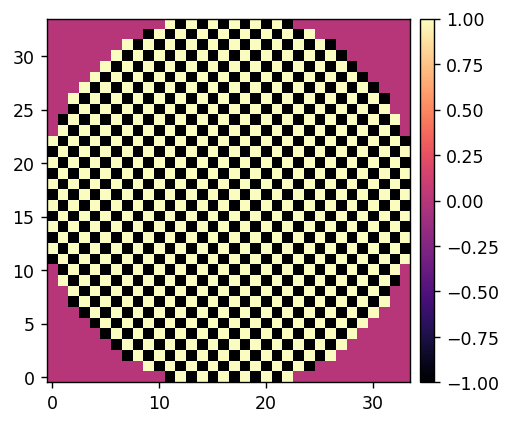

In [120]:
reload(dm)
waffle_command = ensure_np_array(dm.make_fourier_command(x_cpa=17, y_cpa=17)) * dm_mask
utils.imshow([waffle_command])

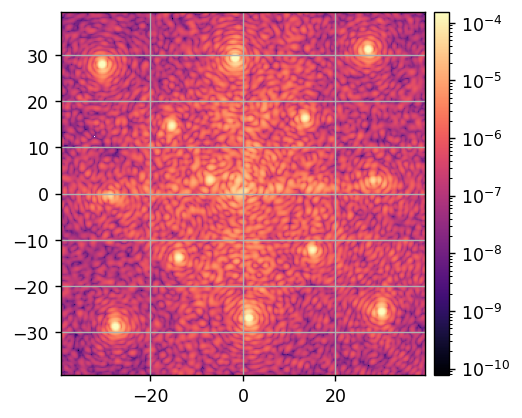

In [121]:
reload(scoobi)
scoobi.set_dm(dm_ho_stream, 10e-9 * waffle_command)
waffle_im = scoobi.snap(camsci_stream, 50, dark_frame, im_params, ref_psf_params)
utils.imshow([waffle_im], norms=[LogNorm()], cmaps=['magma'], grids=[1], pxscls=[camsci_pxscl_lamDc])

Centroids:
 [[ 81.68153849  80.98361909]
 [ 77.42950075 174.88229809]
 [171.22178614 180.26277996]
 [178.          86.        ]
 [ 81.68153849  80.98361909]]


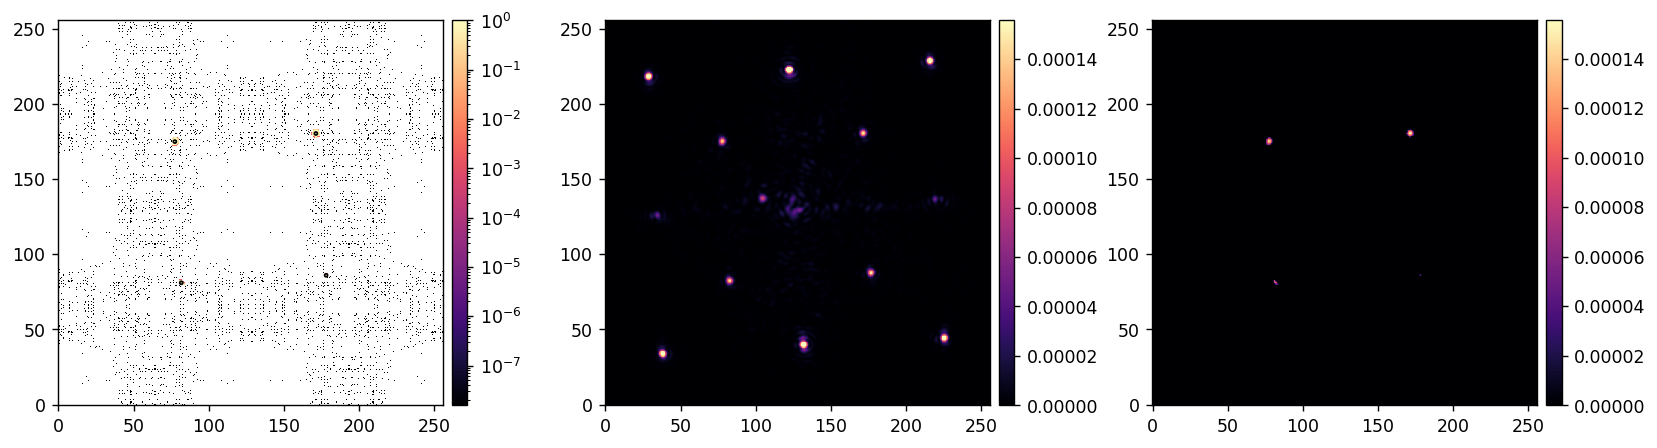

Angle:  86.75743506112241
Measured center in X:  126.92053098936584
Measured center in Y:  131.14306505830308
Required shift in X:  1.0
Required shift in Y:  -3.0


In [127]:
reload(utils)

xshift, yshift, angle = utils.measure_waffle_center_and_angle(
    xp.array(waffle_im), 
    camsci_pxscl_lamDc, 
    im_thresh=5e-5, 
    r_thresh_min=20,
    r_thresh_max=25,
)

# Create the mask defining the dark hole region. 

1022


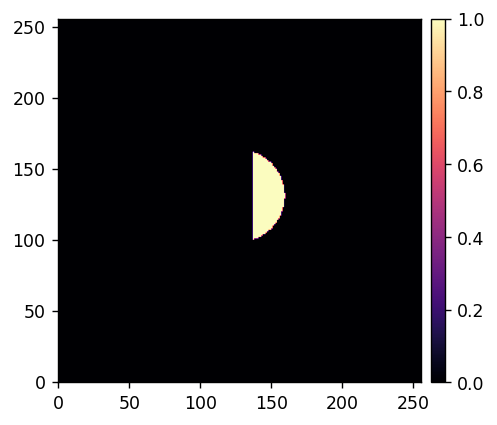

In [128]:
reload(utils)
ncamsci = 256
iwa = 3
owa = 10
rotation = 0
control_mask = ensure_np_array( utils.create_annular_mask(
    ncamsci, 
    camsci_pxscl_lamDc,
    iwa, 
    owa, 
    edge=iwa, 
    x_shift=-xshift,
    y_shift=-yshift,
    rotation=rotation,
))
print(control_mask.sum())
utils.imshow([control_mask])

In [129]:
scoobi.set_fib_atten(0, client)
scoobi.set_cam_exp_time(0.005, client0, cam_name=camsci_name)
scoobi.set_cam_gain(120, client0, cam_name=camsci_name)

im_params = scoobi.get_im_params(client0, client, cam_name=camsci_name)
im_params.update({'atten':0.0})
print(im_params)

Set the fiber attenuation to 0.0
Set the camlo exposure time to 5.00e-03s
Set the camlo gain setting to 120.0
{'texp': 0.00499999988824129, 'gain': 120.0, 'atten': 0.0}


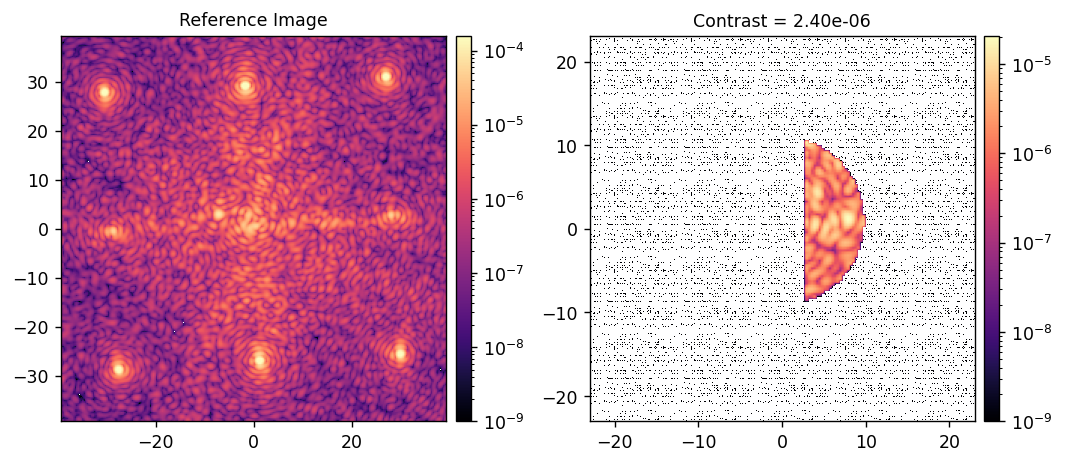

In [130]:
scoobi.zero_dm(dm_ho_stream)

ref_coro_im = scoobi.snap(camsci_stream, 100, dark_frame, im_params, ref_psf_params)
ref_contrast = np.mean(ref_coro_im[control_mask])
utils.imshow(
    [ref_coro_im, control_mask * ref_coro_im],
    titles=['Reference Image', f'Contrast = {ref_contrast:.2e}'],
    norms=[LogNorm(1e-9), LogNorm(1e-9)],
    pxscls=[camsci_pxscl_lamDc]*3,
    cmaps=['magma']*3,
    npix=[None, 150],
)

# Create the probe commands and the calibration modes to be used. 

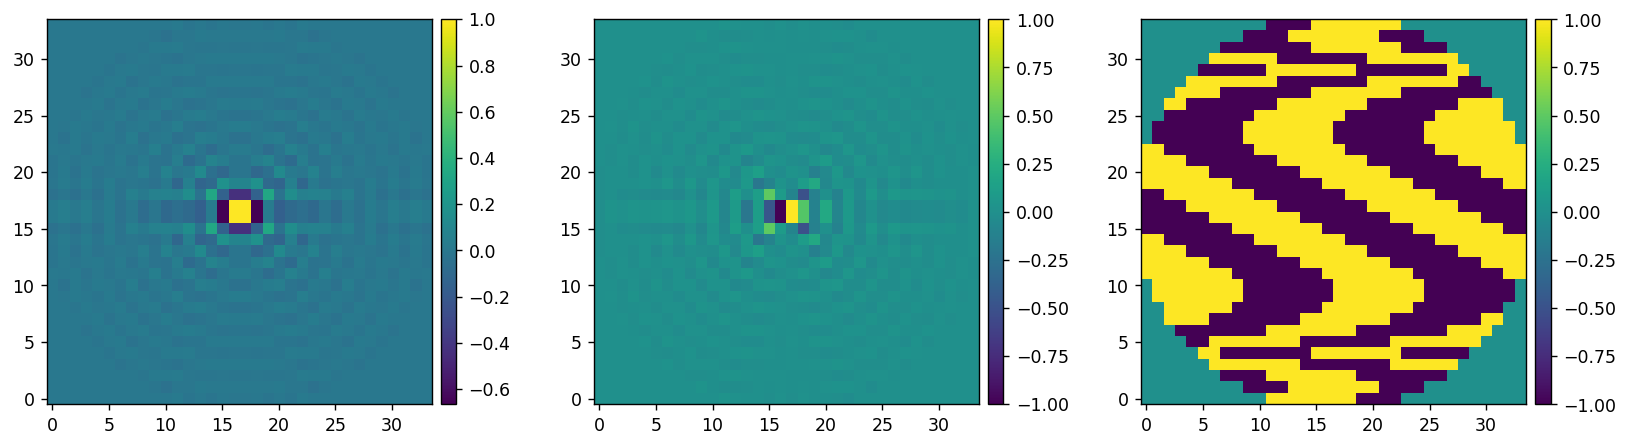

In [131]:
reload(utils)
reload(dm)
probe_iwa = 2
probe_owa = 15

fourier_probes = ensure_np_array(dm.create_fourier_probes(
    xp.array(dm_mask), 
    ncamsci,
    camsci_pxscl_lamDc,
    probe_iwa,
    probe_owa,
    # edge=probe_iwa,
    fourier_sampling=0.75, 
    # rotation=90,
    nprobes=2,
    # plot=True,
    use_weighting=True,
))

calib_modes = ensure_np_array( dm.create_hadamard_modes(xp.array(dm_mask)) ) 
modal_matrix = calib_modes.reshape(calib_modes.shape[0], -1).T

utils.imshow([fourier_probes[0], fourier_probes[1], calib_modes[8]], cmaps=3*['viridis'])

# Test the probes.

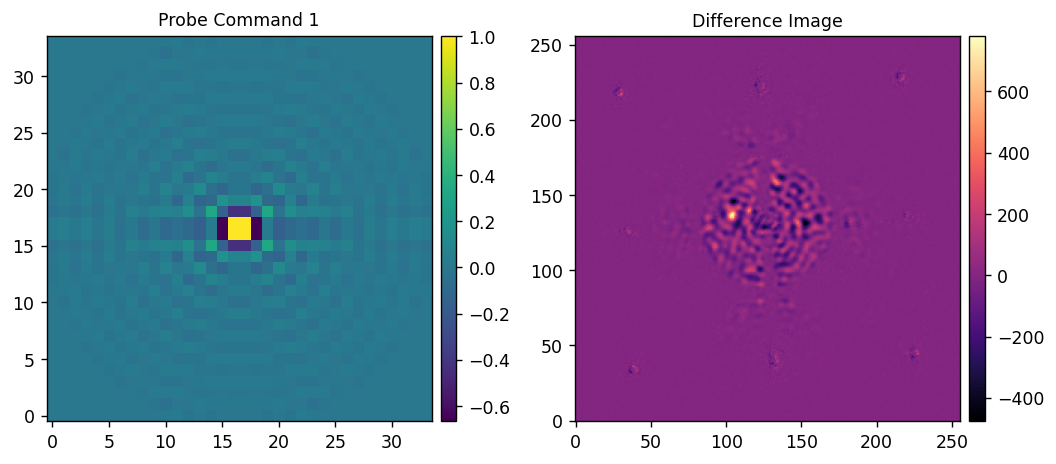

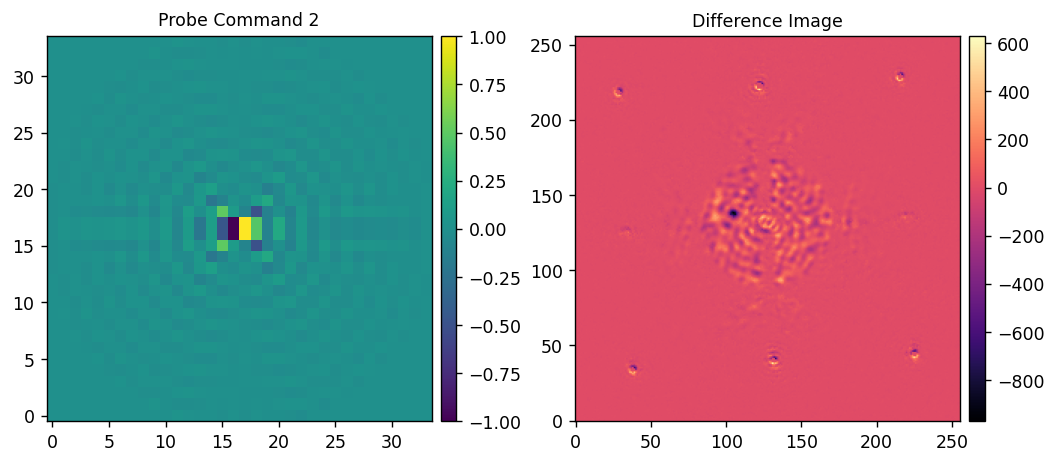

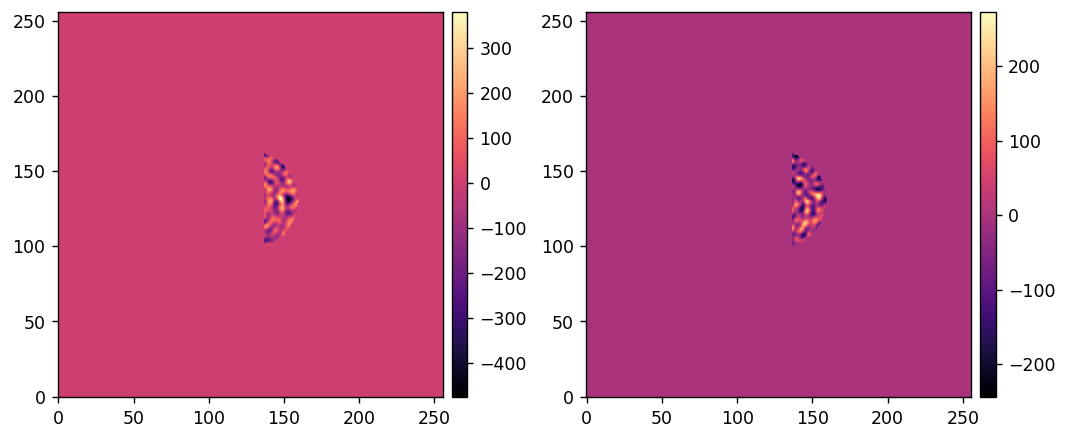

In [134]:
reload(iefc)
scoobi.zero_dm(dm_ho_stream)

diff_ims = iefc.take_measurement(
    camsci_stream, 
    dm_ho_stream, 
    im_params,
    ref_psf_params,
    fourier_probes,
    probe_amplitude=2e-9,
    NFRAMES=25,
    plot=True, 
)
diff_ims *= control_mask
utils.imshow([diff_ims[0], diff_ims[1]])

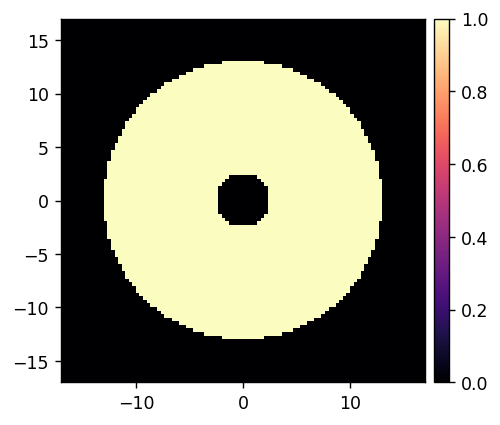

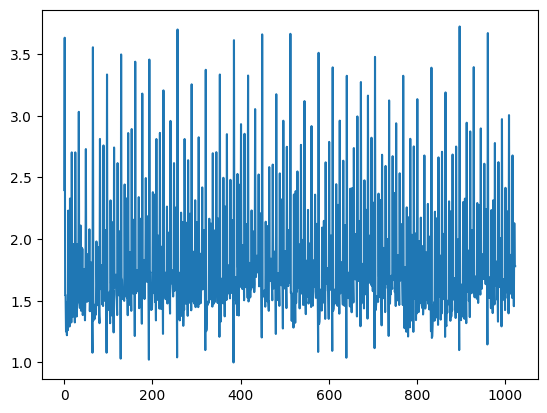

In [133]:
reload(iefc)
scale_factors = iefc.compute_hadamard_scale_factors(xp.array(calib_modes), scale_exp=1/5, scale_thresh=4, oversamp=3, plot=True)

# Start telemetry data collection.

In [79]:
reload(telem)
telem.toggle(1, camsci_name, client0)
telem.toggle(1, dm_ho_name, client0)

Calibrating iEFC...
	Calibrated mode 1024/1024 in 1491.097s
Calibration complete.


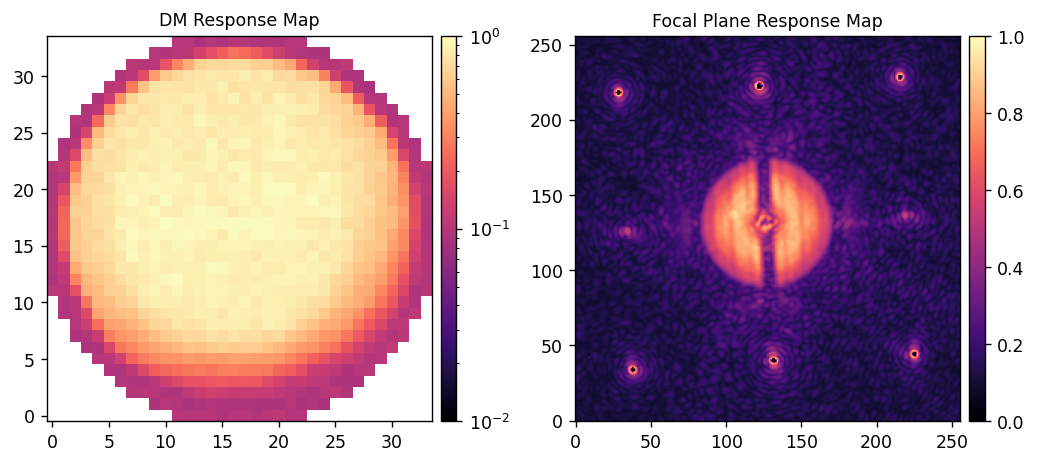

In [135]:
reload(iefc)
scoobi.zero_dm(dm_ho_stream)

probe_amp = 2e-9
calib_amp = 2e-9

NFRAMES = 25

response_matrix, response_cube = iefc.calibrate(
    camsci_stream, 
    dm_ho_stream, 
    control_mask, 
    probe_amp, 
    fourier_probes, 
    calib_amp, 
    calib_modes[:],
    im_params,
    ref_psf_params,
    NFRAMES=NFRAMES,
    delay=0.01,
    scale_factors=scale_factors, 
    plot_responses=True, 
)

In [136]:
iefc_calib_data = {
    'response_matrix':response_matrix,
    'response_cube':response_cube,
    'control_mask':control_mask,
    'NFRAMES':NFRAMES,
    'probe_amp':probe_amp,
    'probe_modes':fourier_probes,
    'calib_amp':calib_amp,
    'scale_factors':scale_factors,
}
utils.save_pickle(iefc_data_path/f'calib_data_lr.pkl', iefc_calib_data)
utils.save_pickle(iefc_data_path/f'calib_im_params.pkl', im_params)

Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250415/iefc/calib_data_lr.pkl
Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250415/iefc/calib_im_params.pkl


In [ ]:
# calib_data = utils.load_pickle(iefc_data_path/f'{today}_iefc_calib_lr.pkl')
# response_cube = response_cube['response_cube']
# response_matrix = response_cube[:, :, control_mask.ravel()].reshape(1024, -1).T

In [83]:
scoobi.zero_dm(dm_ho_stream)

In [137]:
reload(utils)
cm20 = utils.beta_reg(response_matrix, -2, return_np=1)
cm25 = utils.beta_reg(response_matrix, -2.5, return_np=1)
cm50 = utils.beta_reg(response_matrix, -5, return_np=1)
cm60 = utils.beta_reg(response_matrix, -6, return_np=1)


In [140]:
scoobi.set_fib_atten(0, client)
scoobi.set_cam_exp_time(0.005, client0, cam_name=camsci_name)
scoobi.set_cam_gain(120, client0, cam_name=camsci_name)

im_params = scoobi.get_im_params(client0, client, cam_name=camsci_name)
print(im_params)

Set the fiber attenuation to 0.0
Set the camlo exposure time to 5.00e-03s
Set the camlo gain setting to 120.0
{'texp': 0.00499999988824129, 'gain': 120.0, 'atten': 0.0}


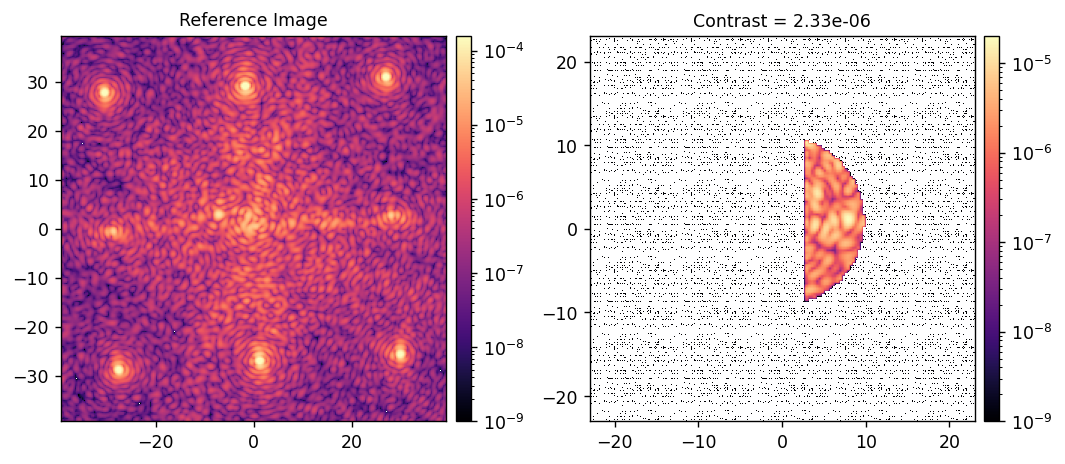

In [141]:
scoobi.zero_dm(dm_ho_stream)

ref_coro_im = scoobi.snap(camsci_stream, 100, dark_frame, im_params, ref_psf_params)
ref_contrast = np.mean(ref_coro_im[control_mask])
utils.imshow(
    [ref_coro_im, control_mask * ref_coro_im],
    titles=['Reference Image', f'Contrast = {ref_contrast:.2e}'],
    norms=[LogNorm(1e-9), LogNorm(1e-9)],
    pxscls=[camsci_pxscl_lamDc]*3,
    cmaps=['magma']*3,
    npix=[None, 150],
)

In [143]:
reload(scoobi)
scoobi.zero_dm(dm_ho_stream)

iefc_data = {
    'images':[ref_coro_im],
    'contrasts':[ref_contrast],
    'commands':[],
    'del_commands':[],
    'pixelscale':camsci_pxscl_lamDc,
    'control_mask':control_mask, 
    'probes':fourier_probes,
}

Running iteration 19 / 21
Measuring dark hole state ...


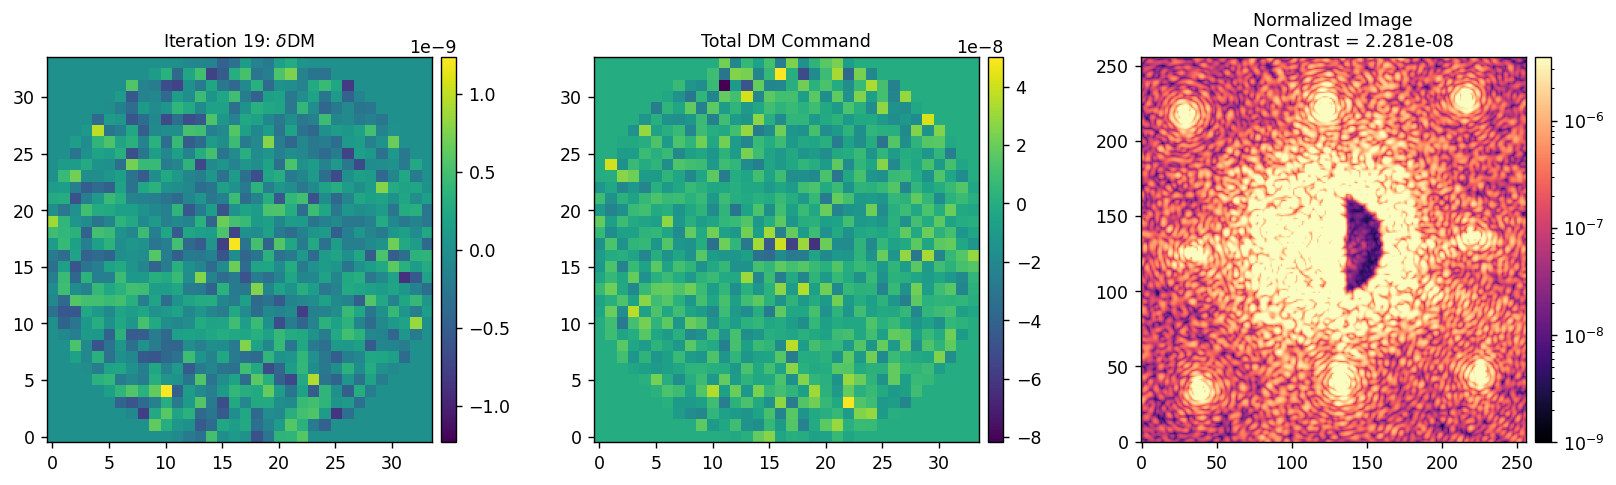

Running iteration 20 / 21
Measuring dark hole state ...


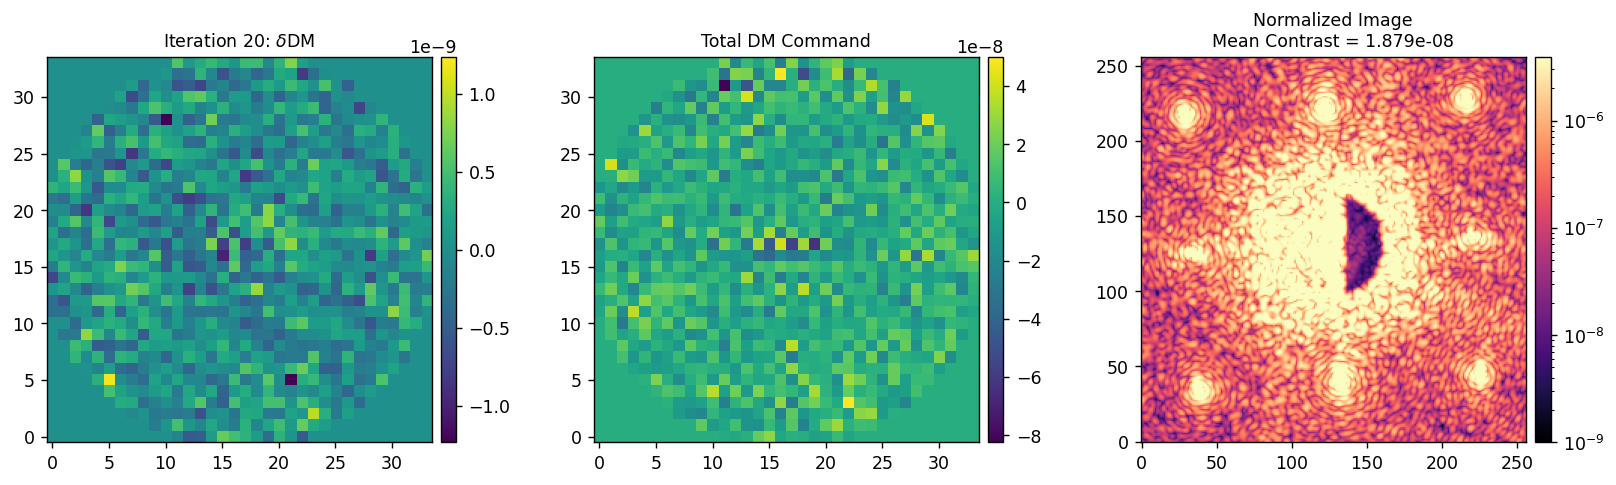

Running iteration 21 / 21
Measuring dark hole state ...


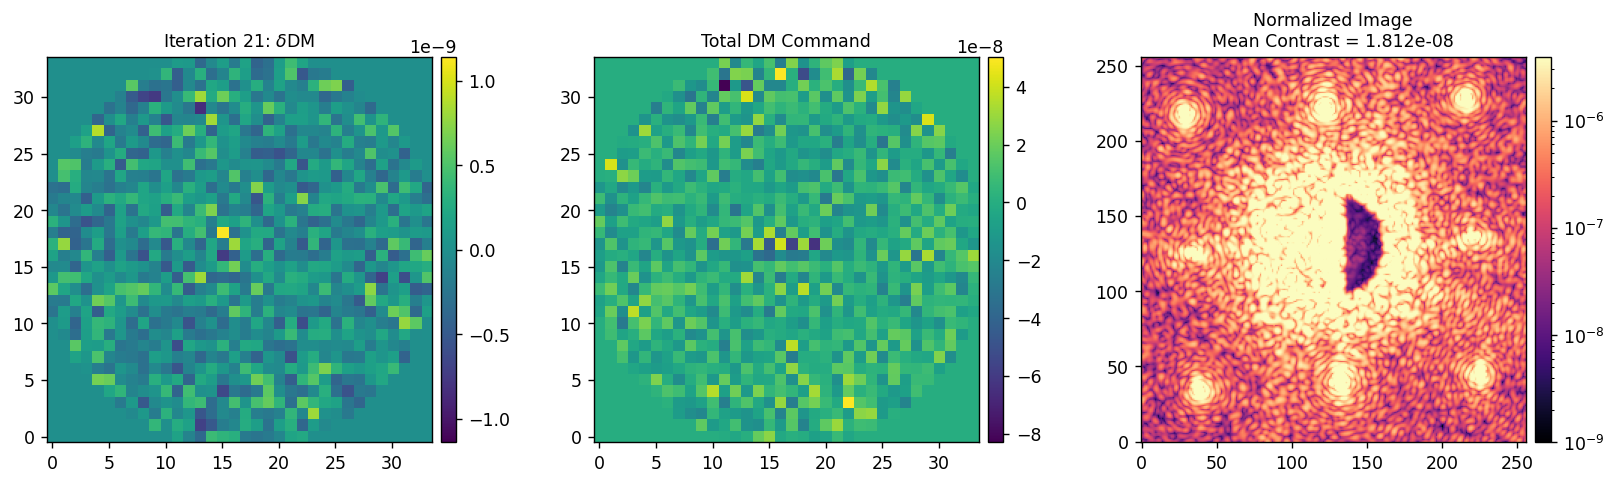

Completed 3 iterations in 48.800s.


In [155]:
reload(utils)
reload(iefc)

probe_amp = 5e-9
probe_amp = 4e-9
probe_amp = 3e-9
probe_amp = 2.5e-9
probe_amp = 2e-9
# probe_amp = 1.5e-9
# probe_amp = 1e-9
probe_amp = 0.75e-9
probe_amp = 0.5e-9
# probe_amp = 0.25e-9

NFRAMES = 25
NFRAMES = 15

iefc_data = iefc.run(
    iefc_data, 
    camsci_stream,
    dm_ho_stream,
    cm20,
    # cm25,
    # cm50,
    # cm60,
    probe_amp, 
    fourier_probes, 
    modal_matrix,
    control_mask,
    im_params,
    ref_psf_params, 
    dark_frame, 
    NFRAMES=NFRAMES, 
    delay=0.01,
    num_iterations=3,
    gain=0.75, 
    leakage=0.0,
    plot_current=True,
    plot_all=True,
    vmin=1e-9,
)

In [98]:
# utils.save_pickle(iefc_data_path/f'{today}_iefc_run_bottom.pkl', iefc_data)
utils.save_pickle(iefc_data_path/f'iefc_run_right.pkl', iefc_data)
utils.save_pickle(iefc_data_path/'iefc_im_params.pkl', im_params)


Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250414/iefc/iefc_run_right.pkl
Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250414/iefc/iefc_im_params.pkl


In [145]:
scoobi.set_fib_atten(0, client)
scoobi.set_cam_exp_time(0.2, client0, cam_name=camsci_name)
scoobi.set_cam_gain(120, client0, cam_name=camsci_name)

im_params = scoobi.get_im_params(client0, client, cam_name=camsci_name)
im_params.update({'atten':0.0})
print(im_params)

Set the fiber attenuation to 0.0
Set the camlo exposure time to 2.00e-01s
Set the camlo gain setting to 120.0
{'texp': 0.200000002980232, 'gain': 120.0, 'atten': 0.0}


In [146]:
reload(scoobi)
scoobi.move_block_in(client0)

143.71786682128908
Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250415/iefc/camsci_dark_frame_0.200000.pkl


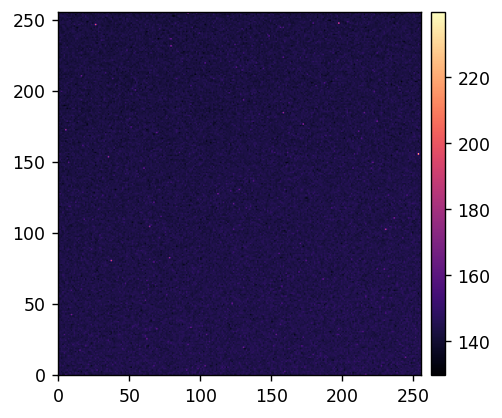

In [147]:
dark_frame = scoobi.snap(camsci_stream, 100)
print(np.mean(dark_frame))
utils.save_pickle(iefc_data_path/f'camsci_dark_frame_{im_params["texp"]:.6f}.pkl', dark_frame)

utils.imshow([dark_frame])

In [148]:
reload(scoobi)
scoobi.move_block_out(client0)

5.552447478650298e-08


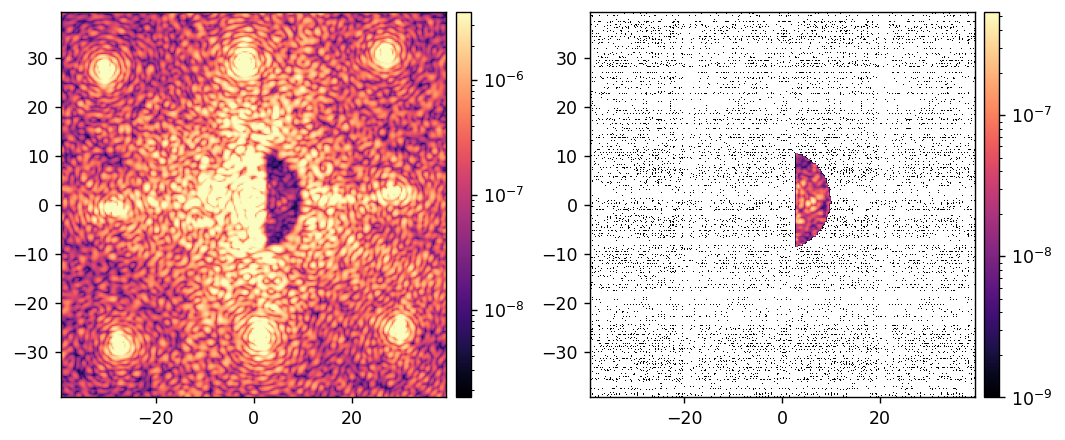

In [149]:
coro_im = scoobi.snap(camsci_stream, 50, dark_frame, im_params, ref_psf_params)
contrast = np.mean(coro_im[control_mask])

print(contrast)
utils.imshow(
    [coro_im, control_mask * coro_im],
    norms=[LogNorm(), LogNorm(1e-9)],
    pxscls=[camsci_pxscl_lamDc]*3,
    cmaps=['magma']*3,
)

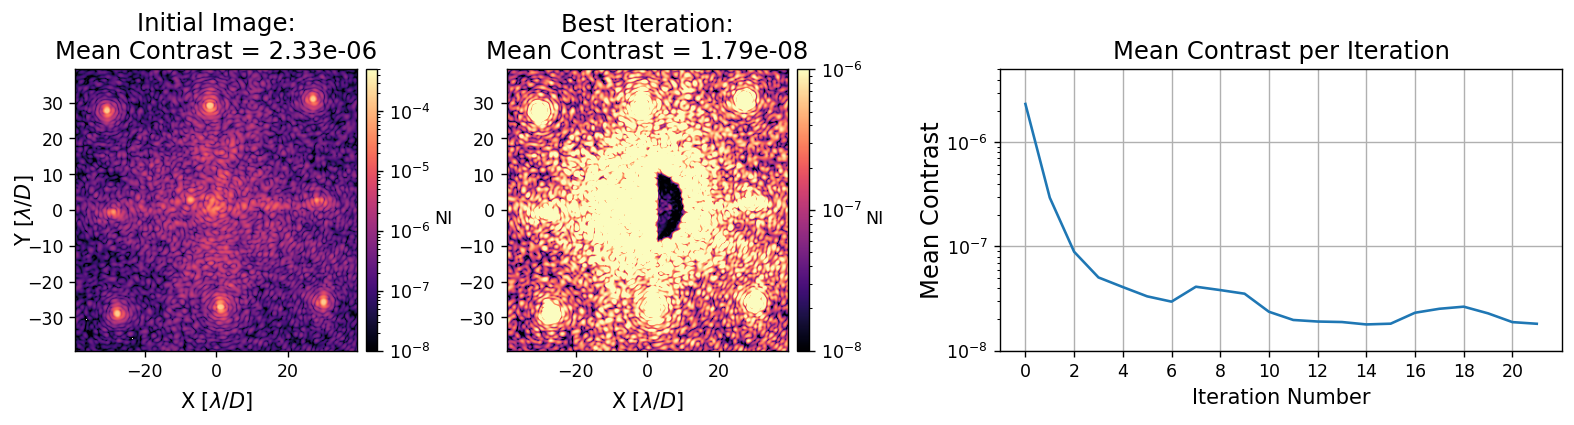

In [156]:
reload(iefc)

iefc.plot_data_with_ref(
    iefc_data,
    im1vmin=1e-8, im1vmax=5e-4,
    im2vmin=1e-8, im2vmax=1e-6, 
    vmin=1e-8, vmax=5e-6,
)

In [158]:
scoobi.set_fib_atten(0, client)
scoobi.set_cam_exp_time(0.005, client0, cam_name=camsci_name)
scoobi.set_cam_gain(120, client0, cam_name=camsci_name)

scoobi.zero_dm(dm_ho_stream)

Set the fiber attenuation to 0.0
Set the camlo exposure time to 5.00e-03s
Set the camlo gain setting to 120.0


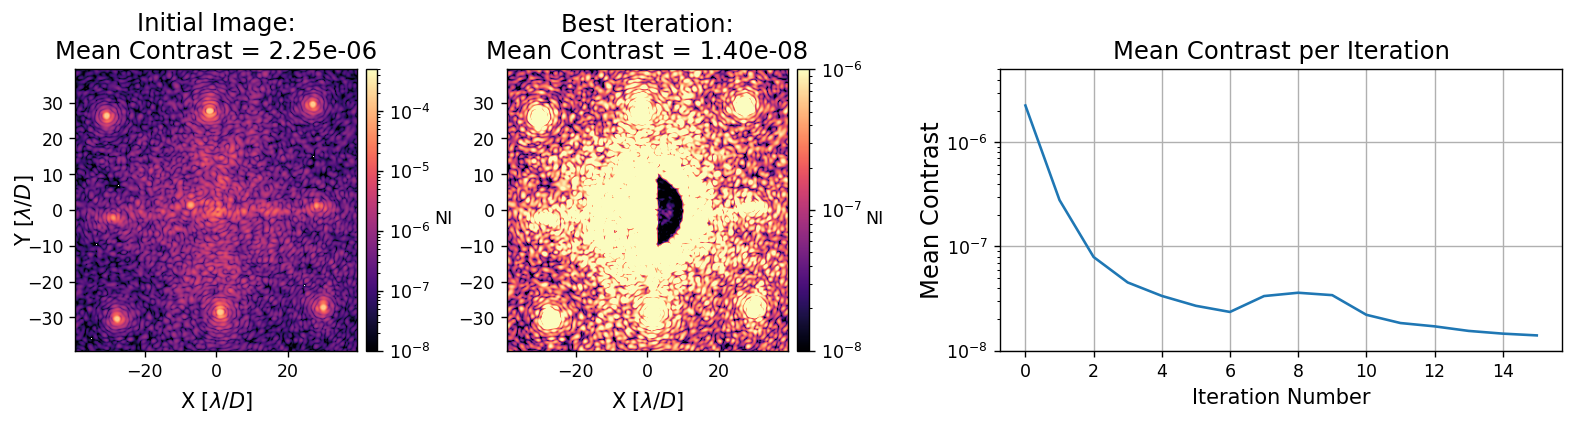

In [99]:
reload(iefc)

iefc.plot_data_with_ref(
    iefc_data,
    im1vmin=1e-8, im1vmax=5e-4,
    im2vmin=1e-8, im2vmax=1e-6, 
    vmin=1e-8, vmax=5e-6,
)

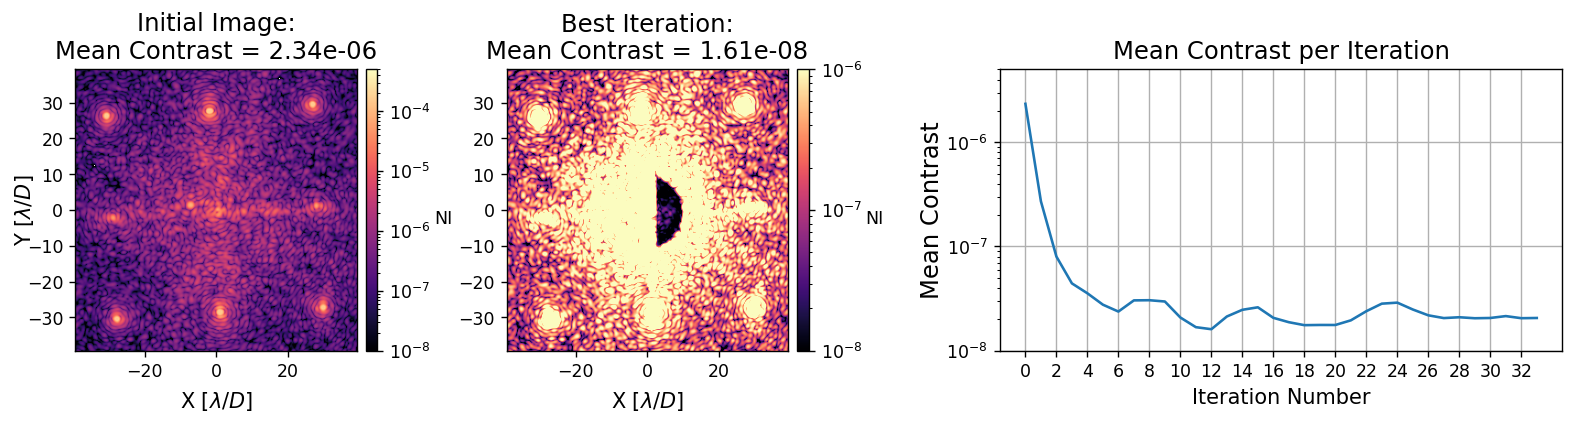

In [126]:
reload(iefc)

iefc.plot_data_with_ref(
    iefc_data,
    im1vmin=1e-8, im1vmax=5e-4,
    im2vmin=1e-8, im2vmax=1e-6, 
    vmin=1e-8, vmax=5e-6,
)

# Stop the telemetry processes at the very end of an experiment.

In [100]:
reload(telem)
telem.toggle(0, camsci_name, client0)
telem.toggle(0, dm_ho_name, client0)

In [101]:
telem.move_files(dm_ho_rawims_path, telem_data_path)
telem.move_files(camsci_rawims_path, telem_data_path)